In [1]:
import numpy as np
import torch
import sklearn
import h5py
import configmypy
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

#Imports for data
import os
from pynwb import NWBHDF5IO
os.makedirs("data", exist_ok=True)

In [2]:
#download the dataset DANDI 000971
!pip install dandi
#download the specific files with the data we need
#RI60 PR (habit formation mimic)
!/home/isr009/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-028-392" --output-dir data

!/home/isr009/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-140-306" --output-dir data

!/home/isr009/.local/bin/dandi download "https://dandiarchive.org/dandiset/000971/0.260213.1851/files?location=sub-100-258" --output-dir data

#specfic files we will look at
keep_files = {
"sub-028-392_ses-FP-PR-2020-07-24T12-31-24.nwb",
"sub-028-392_ses-FP-PR-2020-07-09T13-01-26.nwb",
"sub-140-306_ses-FP-PS-2019-08-09T12-10-58_behavior.nwb",
"sub-140-306_ses-FP-PS-2019-09-03T10-15-44_behavior.nwb",
"sub-100-258_ses-FP-RR20-2019-05-09T13-32-40_behavior.nwb",
"sub-100-258_ses-FP-RR20-2019-04-23T12-25-00_behavior.nwb"
}

data_dir = "data"
#delete unused files 
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.endswith(".nwb") and f not in keep_files:
            path = os.path.join(root, f)
            os.remove(path)
    print("Deleted unused files")

Defaulting to user installation because normal site-packages is not writeable
PATH                                                      SIZE      DONE            DONE% CHECKSUM STATUS          MESSAGE          
sub-028-392/sub-028-392_ses-FP-PR-2020-06-19T12-45-31.nwb 232.0 kB  232.0 kB         100%    ok    done                             
sub-028-392/sub-028-392_ses-FP-PR-2020-06-16T13-05-50.nwb 224.4 kB  224.4 kB         100%    ok    done                             
sub-028-392/sub-028-392_ses-FP-PR-2020-06-17T13-09-45.nwb 229.9 kB  229.9 kB         100%    ok    done                             
sub-028-392/sub-028-392_ses-FP-PR-2020-06-26T13-41-50.nwb 229.9 kB  229.9 kB         100%    ok    done                             
sub-028-392/sub-028-392_ses-FP-PR-2020-06-27T13-51-35.nwb 229.9 kB  229.9 kB         100%    ok    done                             
sub-028-392/sub-028-392_ses-FP-PR-2020-06-28T13-14-50.nwb 229.9 kB  229.9 kB         100%    ok    done                     

In [3]:
#Group files by subject
s028_dir = "data/sub-028-392"
files_028 = [f for f in os.listdir(s028_dir) if f.endswith(".nwb")]

s140_dir = "data/sub-140-306"
files_140 = [f for f in os.listdir(s140_dir) if f.endswith(".nwb")]

s100_dir = "data/sub-100-258"
files_100 = [f for f in os.listdir(s100_dir) if f.endswith(".nwb")]

print(files_028)
print(files_140)
print(files_100)

['sub-028-392_ses-FP-PR-2020-07-24T12-31-24.nwb', 'sub-028-392_ses-FP-PR-2020-07-09T13-01-26.nwb']
['sub-140-306_ses-FP-PS-2019-08-09T12-10-58_behavior.nwb', 'sub-140-306_ses-FP-PS-2019-09-03T10-15-44_behavior.nwb']
['sub-100-258_ses-FP-RR20-2019-05-09T13-32-40_behavior.nwb', 'sub-100-258_ses-FP-RR20-2019-04-23T12-25-00_behavior.nwb']


In [4]:
#extracts dms_signal, dls_signal, and timestamps from files
def load_fp_signal(file_path):

    with NWBHDF5IO(file_path, "r") as io:
        nwb = io.read()

        fp_series = nwb.acquisition['fiber_photometry_response_series']
        raw_signal = fp_series.data[:]

        rate = fp_series.rate
        start = fp_series.starting_time
        timestamps = start + (np.arange(len(raw_signal)) / rate)

        dms_signal = raw_signal[:,0]
        dls_signal = raw_signal[:,2]

    return dms_signal, dls_signal, timestamps

In [5]:
#extracts nose-poke and reward timestamps
def load_behavior_events(file_path):

    with NWBHDF5IO(file_path, "r") as io:
        nwb = io.read()

        behavior = nwb.processing['behavior']

        poke_times = []
        reward_times = []

        for name, obj in behavior.data_interfaces.items():

            if "poke" in name.lower():
                poke_times = obj.timestamps[:]

            if "reward" in name.lower():
                reward_times = obj.timestamps[:]

    return poke_times, reward_times

/home/isr009/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-fiber-photometry': 
 ndx-fiber-photometry defines OpticalFiber.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines ExcitationSource.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines Photodetector.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines DichroicMirror.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines BandOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel.
ndx-fiber-photometry defines EdgeOpticalFilter.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
Thi

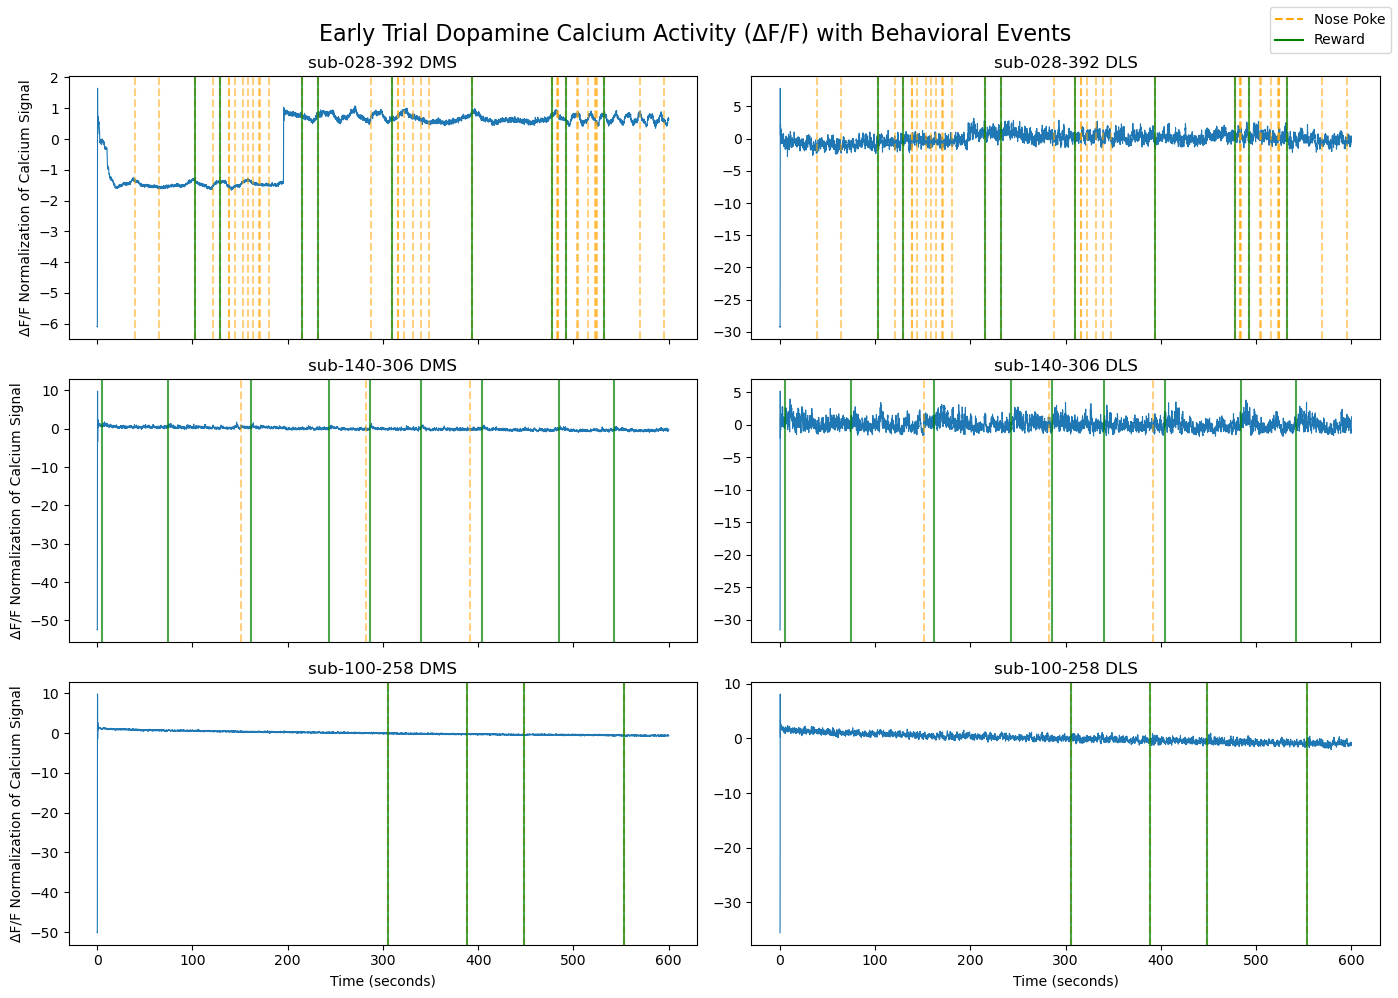

In [6]:
subjects = [
    ("sub-028-392", s028_dir, files_028[1]),
    ("sub-140-306", s140_dir, files_140[0]),
    ("sub-100-258", s100_dir, files_100[0])
]

#plots the normalized fluorescence of calcium in early trial
fig, axes = plt.subplots(3, 2, figsize=(14,10), sharex=True)

for row, (subject, directory, file) in enumerate(subjects):

    path = os.path.join(directory, file)

    dms, dls, t = load_fp_signal(path)
    pokes, rewards = load_behavior_events(path)

    #limits the timeseries to 10 minutes
    mask = (t >= 0) & (t <= 600)

    t_plot = t[mask]
    dms_plot = dms[mask]
    dls_plot = dls[mask]

    #ΔF/F normalization
    ff_dms = (dms_plot - np.mean(dms_plot)) / np.std(dms_plot)
    ff_dls = (dls_plot - np.mean(dls_plot)) / np.std(dls_plot)

    pokes = pokes[(pokes >= 0) & (pokes <= 600)]
    rewards = rewards[(rewards >= 0) & (rewards <= 600)]

    ax_dms = axes[row,0]
    ax_dls = axes[row,1]

    #plots signals
    ax_dms.plot(t_plot, ff_dms, linewidth=0.8)
    ax_dls.plot(t_plot, ff_dls, linewidth=0.8)

    ax_dms.set_title(f"{subject} DMS")
    ax_dls.set_title(f"{subject} DLS")

    #inclusion of event markers
    for p in pokes:
        ax_dms.axvline(p, color="orange", linestyle="--", alpha=0.5)
        ax_dls.axvline(p, color="orange", linestyle="--", alpha=0.5)

    for r in rewards:
        ax_dms.axvline(r, color="green", alpha=0.7)
        ax_dls.axvline(r, color="green", alpha=0.7)

axes[2,0].set_xlabel("Time (seconds)")
axes[2,1].set_xlabel("Time (seconds)")

for i in range(3):
    axes[i,0].set_ylabel("ΔF/F Normalization of Calcium Signal")

fig.suptitle("Early Trial Dopamine Calcium Activity (ΔF/F) with Behavioral Events", fontsize=16)

#import matplotlib.lines as mlines
poke_line = mlines.Line2D([], [], color='orange', linestyle='--', label='Nose Poke')
reward_line = mlines.Line2D([], [], color='green', label='Reward')

fig.legend(handles=[poke_line, reward_line], loc='upper right')

plt.tight_layout()
plt.show()

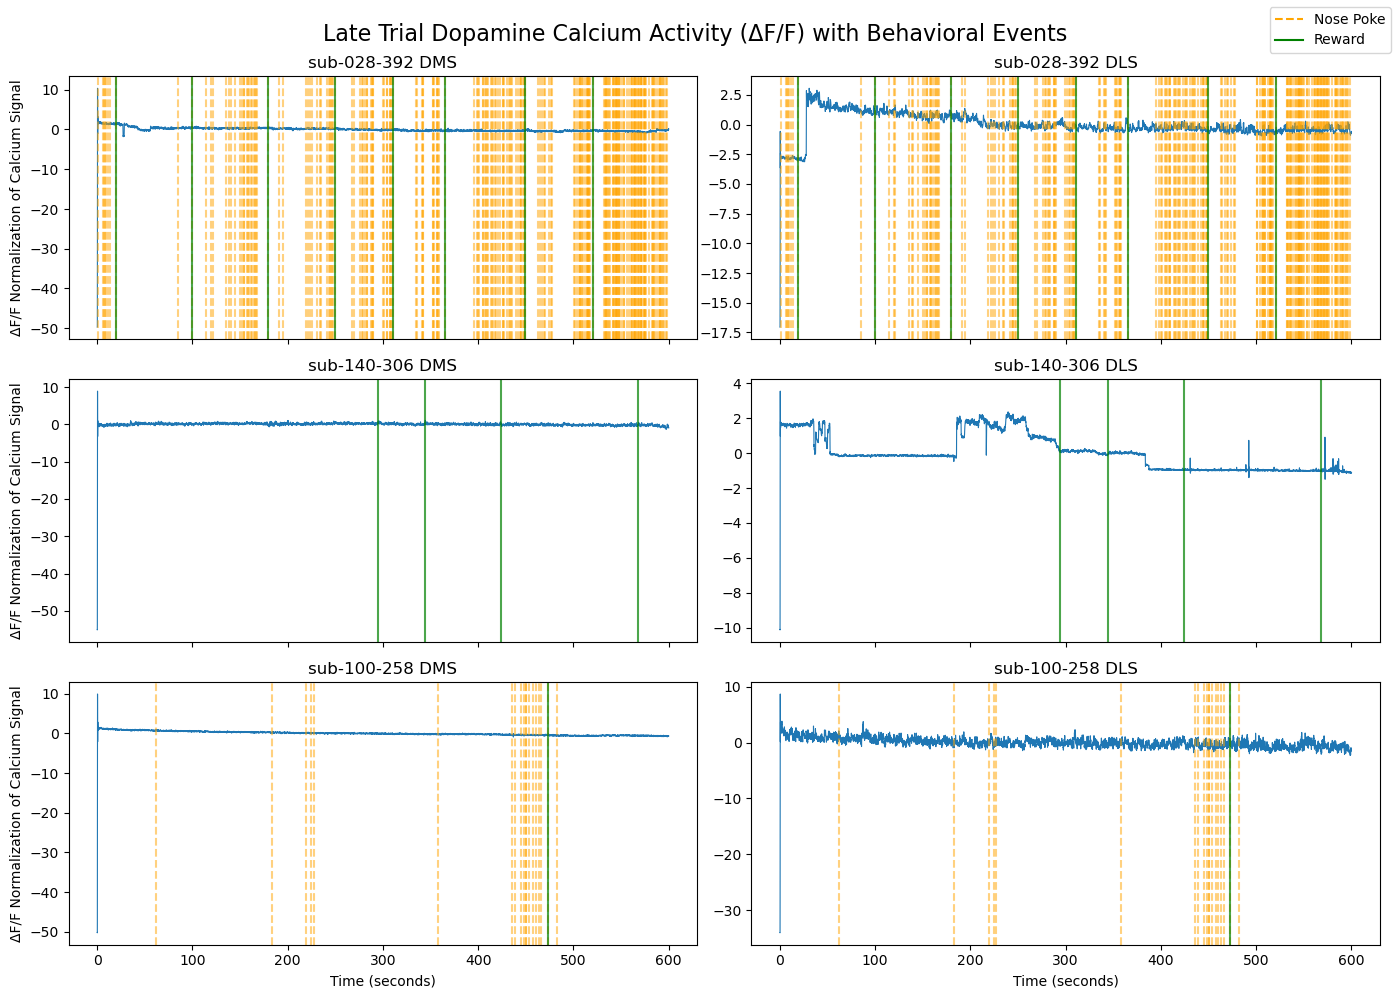

In [7]:
subjects = [
    ("sub-028-392", s028_dir, files_028[0]),
    ("sub-140-306", s140_dir, files_140[1]),
    ("sub-100-258", s100_dir, files_100[1])
]

#plots the normalized fluorescence of calcium in early trial
fig, axes = plt.subplots(3, 2, figsize=(14,10), sharex=True)

for row, (subject, directory, file) in enumerate(subjects):

    path = os.path.join(directory, file)

    dms, dls, t = load_fp_signal(path)
    pokes, rewards = load_behavior_events(path)

    #limits the time series to 10 minutes
    mask = (t >= 0) & (t <= 600)

    t_plot = t[mask]
    dms_plot = dms[mask]
    dls_plot = dls[mask]

    #ΔF/F normalization
    ff_dms = (dms_plot - np.mean(dms_plot)) / np.std(dms_plot)
    ff_dls = (dls_plot - np.mean(dls_plot)) / np.std(dls_plot)

    pokes = pokes[(pokes >= 0) & (pokes <= 600)]
    rewards = rewards[(rewards >= 0) & (rewards <= 600)]

    ax_dms = axes[row,0]
    ax_dls = axes[row,1]

    #plots signals
    ax_dms.plot(t_plot, ff_dms, linewidth=0.8)
    ax_dls.plot(t_plot, ff_dls, linewidth=0.8)

    ax_dms.set_title(f"{subject} DMS")
    ax_dls.set_title(f"{subject} DLS")

    #inclusion of event markers
    for p in pokes:
        ax_dms.axvline(p, color="orange", linestyle="--", alpha=0.5)
        ax_dls.axvline(p, color="orange", linestyle="--", alpha=0.5)

    for r in rewards:
        ax_dms.axvline(r, color="green", alpha=0.7)
        ax_dls.axvline(r, color="green", alpha=0.7)

axes[2,0].set_xlabel("Time (seconds)")
axes[2,1].set_xlabel("Time (seconds)")

for i in range(3):
    axes[i,0].set_ylabel("ΔF/F Normalization of Calcium Signal")

fig.suptitle("Late Trial Dopamine Calcium Activity (ΔF/F) with Behavioral Events", fontsize=16)

#import matplotlib.lines as mlines
poke_line = mlines.Line2D([], [], color='orange', linestyle='--', label='Nose Poke')
reward_line = mlines.Line2D([], [], color='green', label='Reward')

fig.legend(handles=[poke_line, reward_line], loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
#setting up function for extracting time window around event
def extract_event_aligned(signal, timestamps, events, pre=5, post=5):

    aligned = []

    dt = np.median(np.diff(timestamps))
    n_pre = int(pre / dt)
    n_post = int(post / dt)

    for e in events:

        idx = np.searchsorted(timestamps, e)

        start = idx - n_pre
        end = idx + n_post

        if start >= 0 and end < len(signal):
            aligned.append(signal[start:end])

    return np.array(aligned), dt

#setting up function for computing #ΔF/F normalization
def compute_zscore(signal):

    return (signal - np.mean(signal)) / np.std(signal)

#setting up function for calculating mean SEM
def compute_event_average(windows):

    mean = np.mean(windows, axis=0)
    sem = np.std(windows, axis=0) / np.sqrt(len(windows))

    return mean, sem

In [9]:
#seperating trials into early and late trials
subjects = {
    "sub-028-392": {
        "Early Trial": files_028[1],
        "Late Trial": files_028[0]
    },
    "sub-140-306": {
        "Early Trial": files_140[0],
        "Late Trial": files_140[1]
    },
    "sub-100-258": {
        "Early Trial": files_100[0],
        "Late Trial": files_100[1]
    }
}

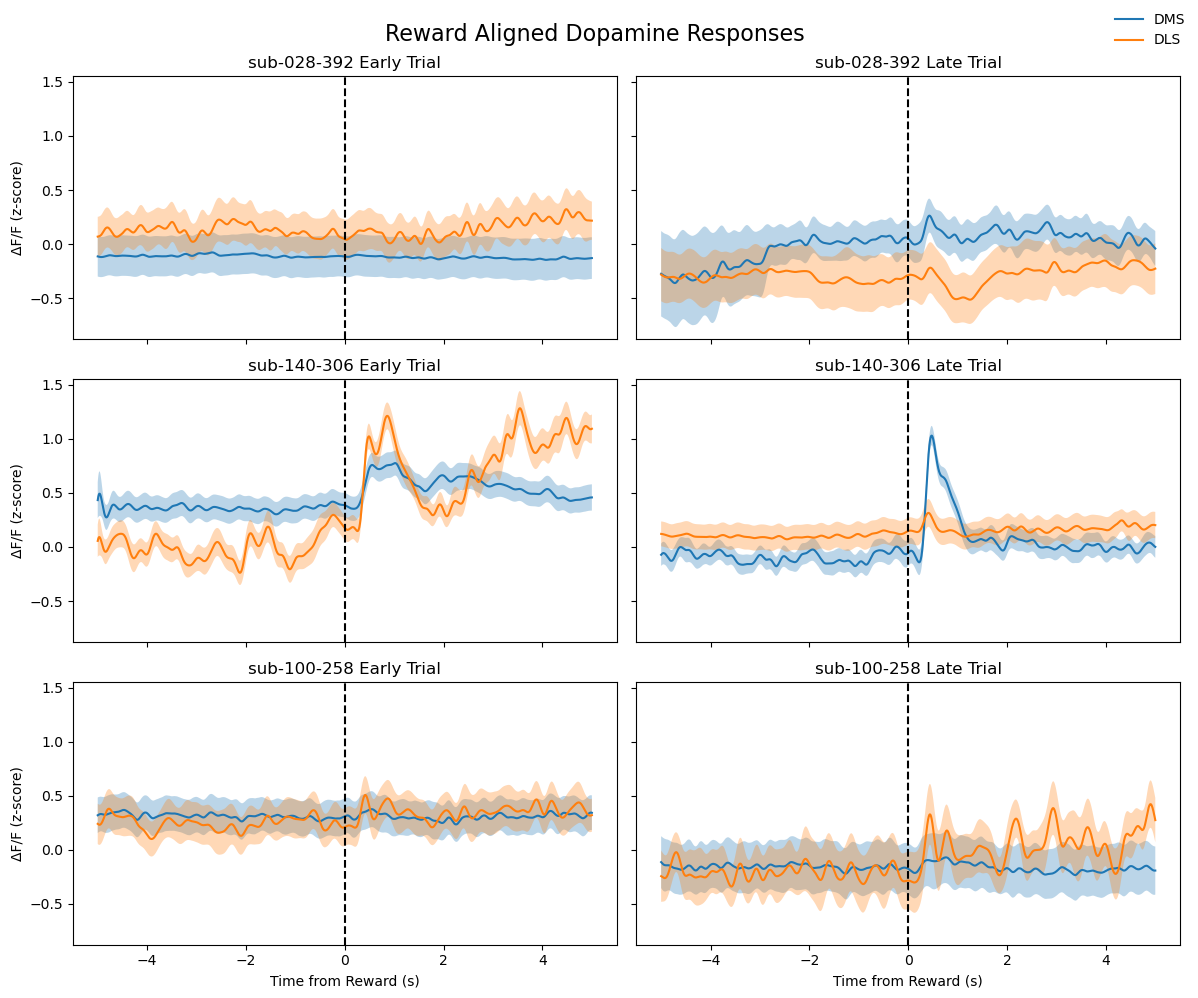

In [10]:
#plotting reward aligned dopamine responses in a 2x3
fig, axes = plt.subplots(3,2, figsize=(12,10), sharex=True, sharey=True)

for row, (subject, sessions) in enumerate(subjects.items()):

    for col, session_type in enumerate(["Early Trial","Late Trial"]):

        file = sessions[session_type]

        if subject == "sub-028-392":
            directory = s028_dir
        elif subject == "sub-140-306":
            directory = s140_dir
        else:
            directory = s100_dir

        path = os.path.join(directory, file)

        dms, dls, t = load_fp_signal(path)
        pokes, rewards = load_behavior_events(path)

        ff_dms = compute_zscore(dms)
        ff_dls = compute_zscore(dls)

        windows_dms, dt = extract_event_aligned(ff_dms, t, rewards)
        windows_dls, _ = extract_event_aligned(ff_dls, t, rewards)

        mean_dms, sem_dms = compute_event_average(windows_dms)
        mean_dls, sem_dls = compute_event_average(windows_dls)

        time_axis = np.linspace(-5,5,len(mean_dms))

        ax = axes[row,col]

        ax.plot(time_axis, mean_dms, label="DMS")
        ax.plot(time_axis, mean_dls, label="DLS")

        ax.fill_between(time_axis,
                        mean_dms-sem_dms,
                        mean_dms+sem_dms,
                        alpha=0.3)

        ax.fill_between(time_axis,
                        mean_dls-sem_dls,
                        mean_dls+sem_dls,
                        alpha=0.3)

        ax.axvline(0, color="black", linestyle="--")

        ax.set_title(f"{subject} {session_type}")

axes[2,0].set_xlabel("Time from Reward (s)")
axes[2,1].set_xlabel("Time from Reward (s)")

for i in range(3):
    axes[i,0].set_ylabel("ΔF/F (z-score)")

fig.suptitle("Reward Aligned Dopamine Responses", fontsize=16)

fig.legend(
    labels=["DMS", "DLS"],
    loc="upper right",
    frameon=False)
plt.tight_layout()
plt.show()

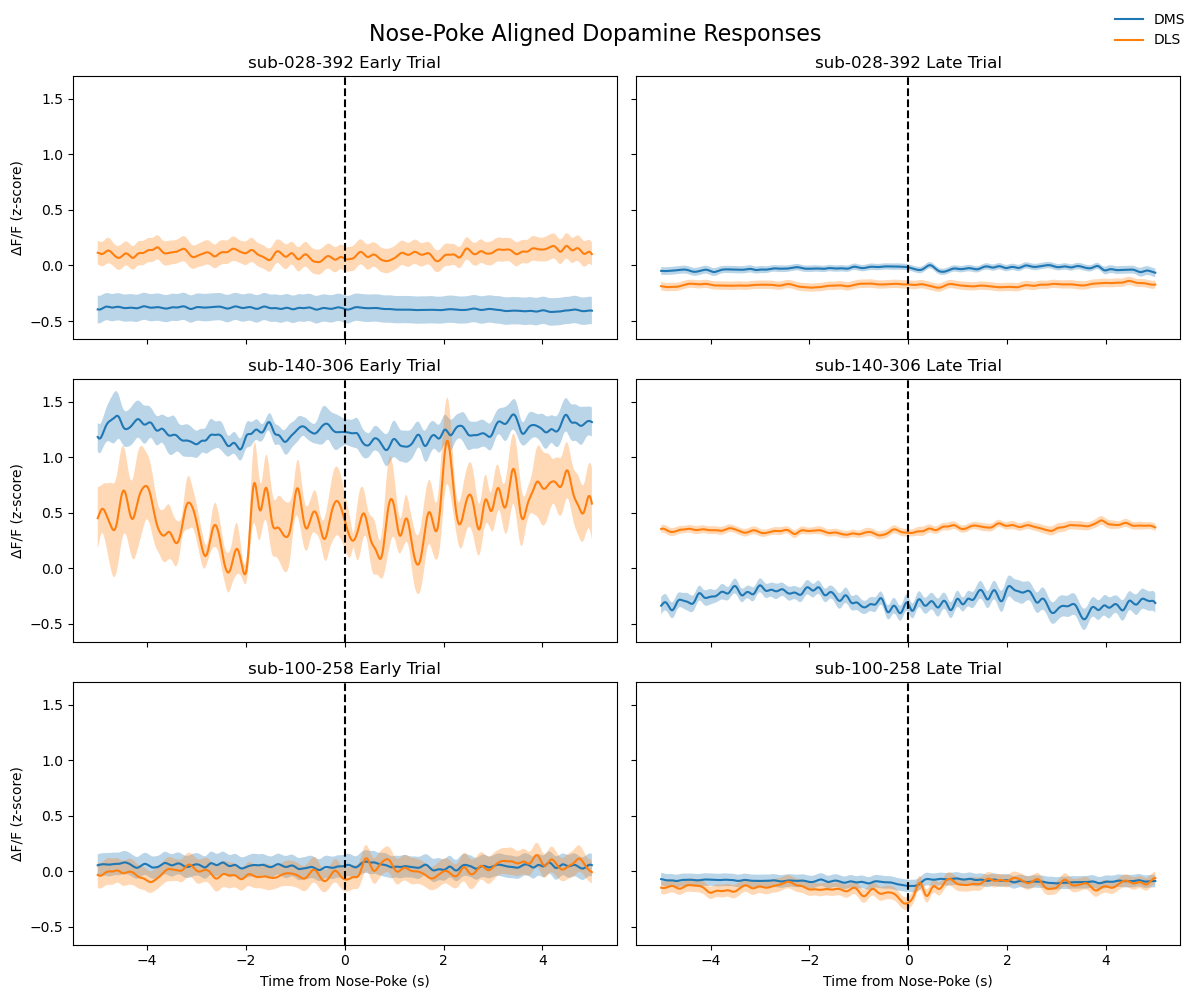

In [11]:
#plotting nose-poke aligned dopamine responses in a 2x3
fig, axes = plt.subplots(3,2, figsize=(12,10), sharex=True, sharey=True)

for row, (subject, sessions) in enumerate(subjects.items()):

    for col, session_type in enumerate(["Early Trial","Late Trial"]):

        file = sessions[session_type]

        if subject == "sub-028-392":
            directory = s028_dir
        elif subject == "sub-140-306":
            directory = s140_dir
        else:
            directory = s100_dir

        path = os.path.join(directory, file)

        dms, dls, t = load_fp_signal(path)
        pokes, rewards = load_behavior_events(path)

        ff_dms = compute_zscore(dms)
        ff_dls = compute_zscore(dls)

        windows_dms, dt = extract_event_aligned(ff_dms, t, pokes)
        windows_dls, _ = extract_event_aligned(ff_dls, t, pokes)

        mean_dms, sem_dms = compute_event_average(windows_dms)
        mean_dls, sem_dls = compute_event_average(windows_dls)

        time_axis = np.linspace(-5,5,len(mean_dms))

        ax = axes[row,col]

        ax.plot(time_axis, mean_dms, label="DMS")
        ax.plot(time_axis, mean_dls, label="DLS")

        ax.fill_between(time_axis,
                        mean_dms-sem_dms,
                        mean_dms+sem_dms,
                        alpha=0.3)

        ax.fill_between(time_axis,
                        mean_dls-sem_dls,
                        mean_dls+sem_dls,
                        alpha=0.3)

        ax.axvline(0, color="black", linestyle="--")

        ax.set_title(f"{subject} {session_type}")

axes[2,0].set_xlabel("Time from Nose-Poke (s)")
axes[2,1].set_xlabel("Time from Nose-Poke (s)")

for i in range(3):
    axes[i,0].set_ylabel("ΔF/F (z-score)")

fig.suptitle("Nose-Poke Aligned Dopamine Responses", fontsize=16)

fig.legend(
    labels=["DMS", "DLS"],
    loc="upper right",
    frameon=False)

plt.tight_layout()
plt.show()